#### ●	Objective: To compute and analyze basic statistical measures for numerical columns in the dataset.
#### ●	Steps:
	Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
	Identify numerical columns in the dataset.
	Calculate the mean, median, mode, and standard deviation for these columns.
	Provide a brief interpretation of these statistics.


In [3]:
import pandas as pd

In [4]:
#Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
df=pd.read_csv('sales_data_with_discounts.csv')

In [5]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [6]:
#Identify numerical columns in the dataset.
numeric_cols=df.select_dtypes(include='number')
numeric_cols

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...
445,2,1300,2600,15.475687,402.367873,2197.632127
446,6,2600,15600,17.057027,2660.896242,12939.103758
447,2,1600,3200,18.965550,606.897606,2593.102394
448,3,1900,5700,16.793014,957.201826,4742.798174


In [7]:
#Calculate the mean, median, mode, and standard deviation for these columns
mean_df=df.mean(numeric_only=True)
mean_df

Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

In [8]:
median_df=df.median(numeric_only=True)
median_df

Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

In [9]:
mode_df=df.mean(numeric_only=True)
mode_df

Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

In [10]:
std_df=df.std(numeric_only=True)
std_df

Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64

#### Interpretation
#### Volume: Average volume per record is about 5 units with a median of 4, indicating slightly right-skewed volumes with most transactions involving small quantities and some higher-volume outliers.

#### Avg Price: Mean price is much higher than the median, showing that a few very high-priced SKUs (e.g., mobiles, lifestyle items) pull the average up, while many FMCG items cluster at low prices (mode 400).

#### Total Sales Value: Very high standard deviation and mean > median indicate large variability in bill values, with a few very large sales compared to many smaller ones.

#### Discount Rate (%): Mean and median are close (around 15–16.6%), suggesting discount percentages are relatively consistent, with moderate spread (std ≈ 4.2%).

#### Discount Amount: High standard deviation relative to the mean shows discount rupee amounts vary greatly, driven by both price and volume differences across transactions.

#### Net Sales Value: Since it is derived from Total Sales Value minus Discount Amount, its distribution mirrors total sales but slightly reduced, still showing high variability across records.


# Data Vizualization 

Data Visualization
●	Objective: To visualize the distribution and relationship of numerical and categorical variables in the dataset.
●	Histograms:
	Plot histograms for each numerical column.
	Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.
●	Box Plots:
	Create boxplots for numerical variables to identify outliers and the interquartile range.
	Discuss any findings, such as extreme values or unusual distributions.
●	Bar Chart Analysis for Categorical Column:
	Identify categorical columns in the dataset.
	Create bar charts to visualize the frequency or count of each category.
	Analyze the distribution of categories and provide insights.


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

## Hist plot

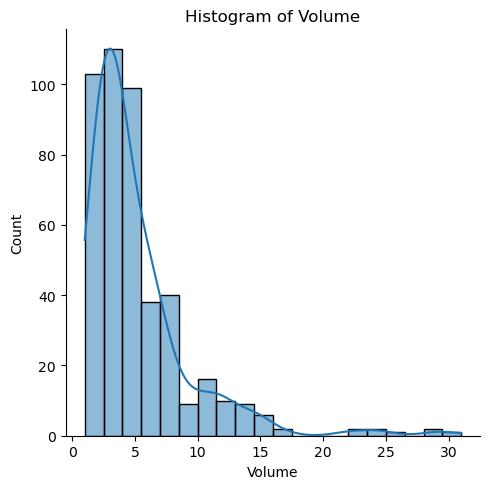

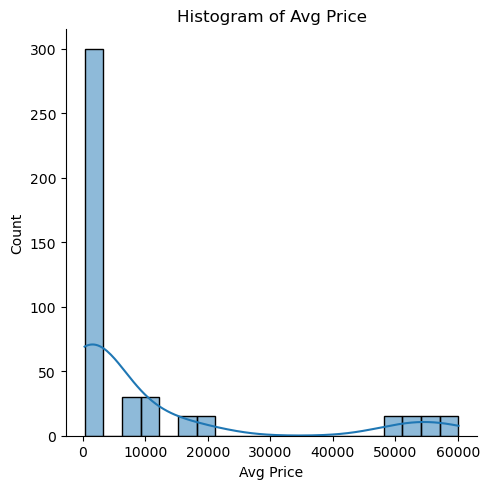

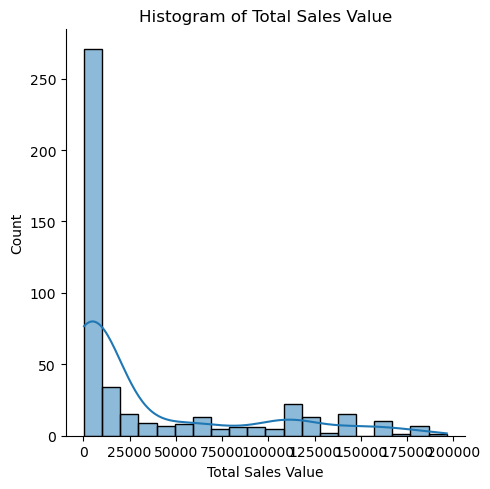

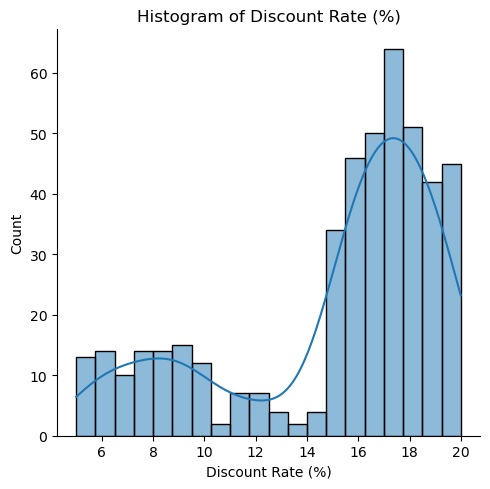

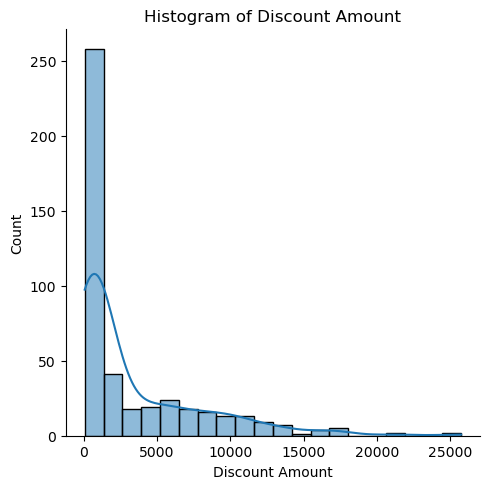

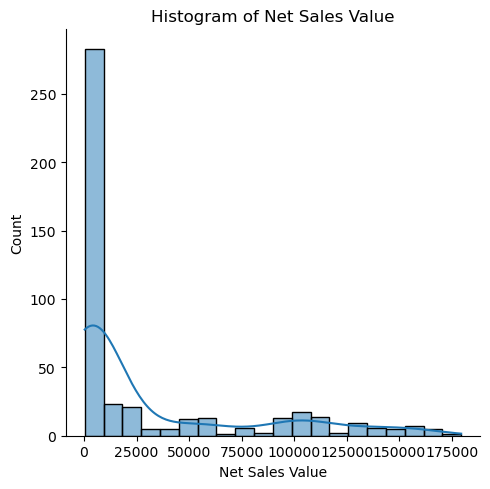

In [14]:
for col in numeric_cols:
    sns.displot(data=df, x=col, bins=20, kde=True)
    plt.title(f"Histogram of {col}")
    plt.tight_layout()
    plt.show()


### Inference
#### For Volume, the histogram (displot with ~20 bins) is concentrated at low unit counts (1–5), with a long right tail showing occasional higher-volume orders, indicating positive skew and some larger bulk purchases.
#### Avg Price, Total Sales Value, Discount Amount, and Net Sales Value all show heavy right skew: many records with low to moderate values (e.g., FMCG) and a small number of high-priced mobile/lifestyle transactions forming a long tail, suggesting strong heterogeneity in ticket sizes and discount rupees
#### Discount Rate (%) is more tightly clustered, with most observations around mid-teens, indicating discount percentages are relatively consistent even though the corresponding rupee discount amounts vary widely.

## Boxplot

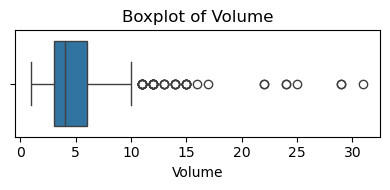

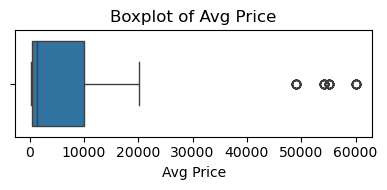

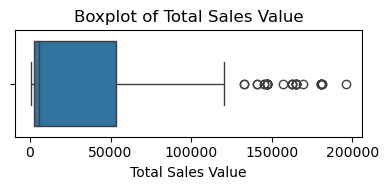

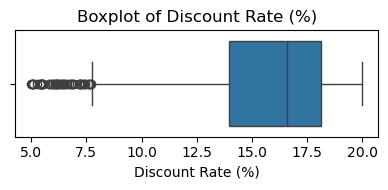

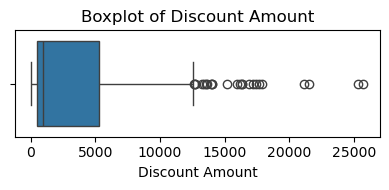

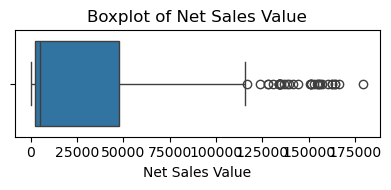

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(4, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

### Boxplots and outliers
#### The Volume boxplot shows a compact interquartile range (IQR) at low volumes and several points above the upper whisker, confirming the presence of high-volume outliers compared to typical orders.
#### Boxplots for Avg Price, Total Sales Value, Discount Amount, and Net Sales Value display very tall whiskers and many extreme points, which correspond to high-value mobile and lifestyle sales; this confirms that a small fraction of records contribute disproportionately to revenue and discounts
#### The Discount Rate (%) boxplot has a relatively narrow IQR with fewer outliers, reinforcing that discount policy is fairly stable, and unusual percentage discounts are rare compared to unusual transaction sizes.


## Bar Chart

In [26]:
cat_cols=df.select_dtypes(exclude='number')
cat_cols

,Date,Day,SKU,City,BU,Brand,Model
0,01-04-2021,Thursday,M01,C,Mobiles,RealU,RU-10
1,01-04-2021,Thursday,M02,C,Mobiles,RealU,RU-9 Plus
2,01-04-2021,Thursday,M03,C,Mobiles,YouM,YM-99
3,01-04-2021,Thursday,M04,C,Mobiles,YouM,YM-99 Plus
4,01-04-2021,Thursday,M05,C,Mobiles,YouM,YM-98
...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,Lifestyle,Jeera,M-Casuals
446,15-04-2021,Thursday,L07,C,Lifestyle,Viva,W-Western
447,15-04-2021,Thursday,L08,C,Lifestyle,Viva,W-Lounge
448,15-04-2021,Thursday,L09,C,Lifestyle,Jeera,M-Formals


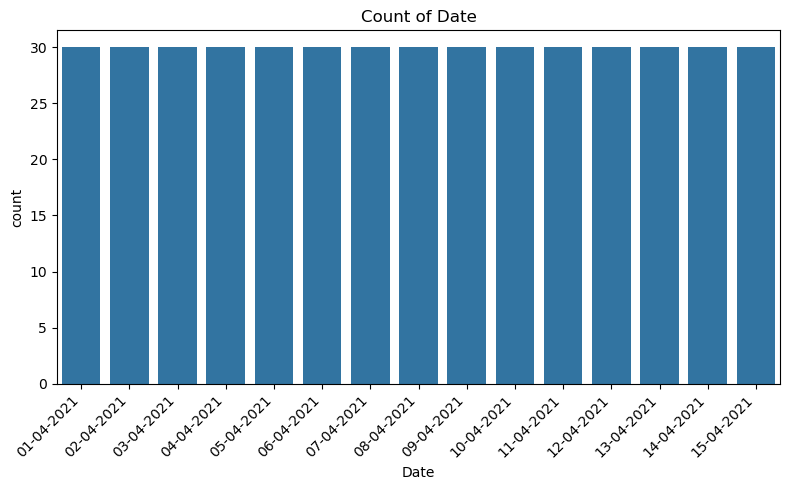

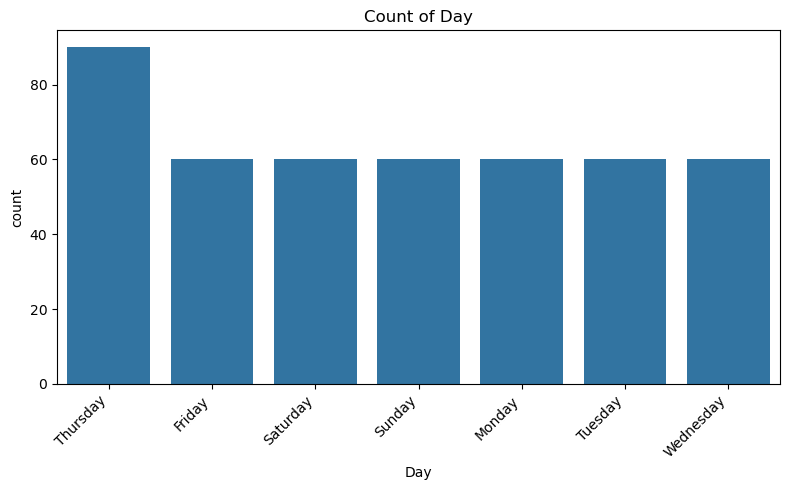

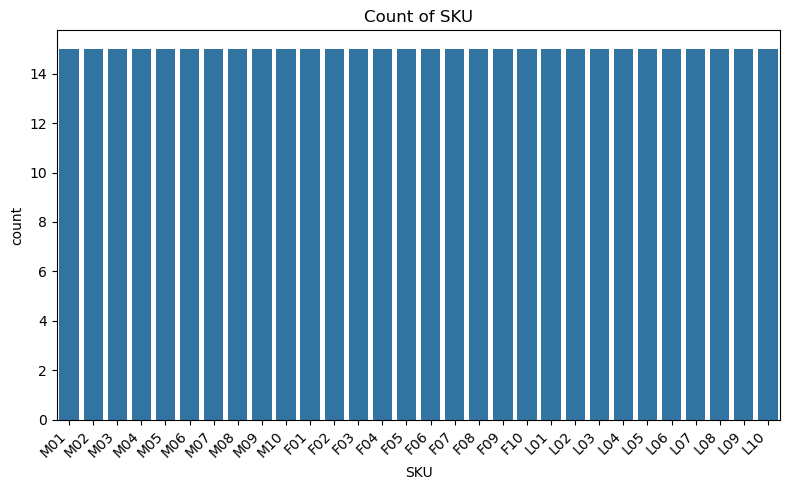

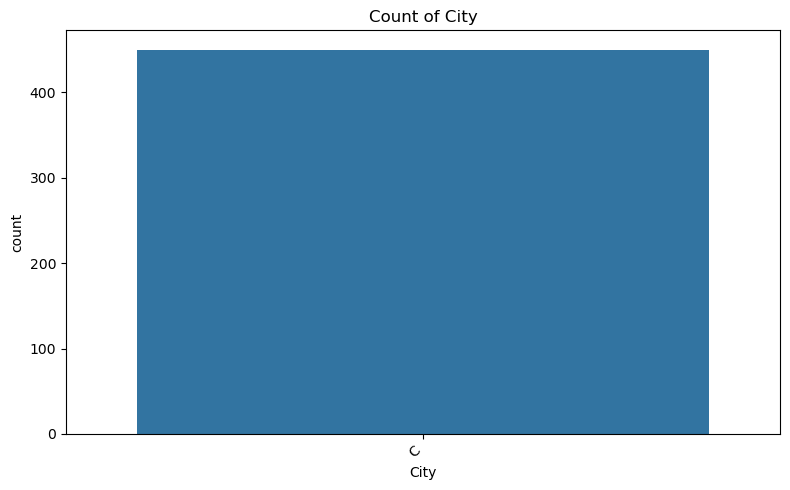

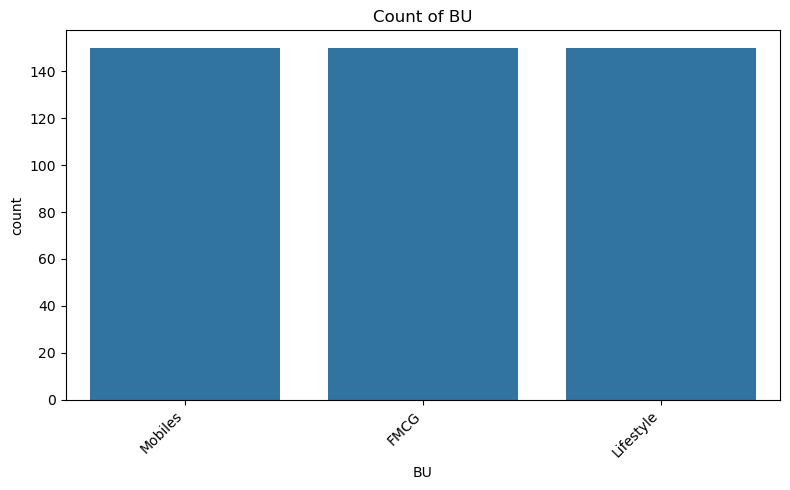

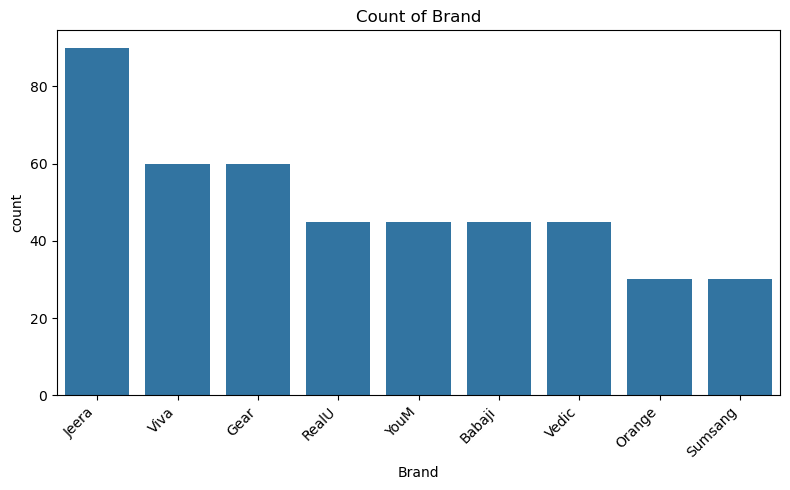

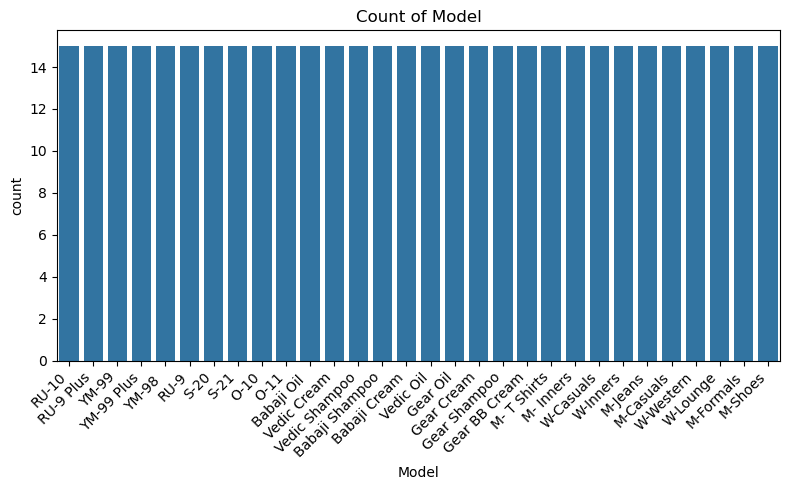

In [29]:
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    # For many levels, rotate x labels
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Inference 
#### BU, Brand, and Model
#### The BU bar chart shows three main business units (Mobiles, FMCG, Lifestyle), with FMCG appearing very frequently and Mobiles/Lifestyle somewhat less frequent, implying many low-ticket FMCG transactions versus fewer high-ticket mobile and lifestyle items.
#### Within Brand and Model, a limited group (RealU, YouM, Sumsang, Orange for mobiles; Babaji, Vedic, Gear for FMCG; Jeera, Viva for lifestyle) appears repeatedly, indicating a focused SKU assortment where a handful of models drive most of the volume.
#### Date and Day
#### The Date and Day bar charts are fairly uniform across the covered period and weekdays/weekend, suggesting that sales are spread reasonably evenly over time with no single date or day showing a drastic spike or drop in transaction counts.


## Descriptive statistics
#### Average Volume per line is low (around 4–5 units) and slightly right‑skewed, indicating most orders are small with a few larger-quantity purchases.

#### Monetary variables (Avg Price, Total Sales Value, Discount Amount, Net Sales Value) have means much higher than their medians and very large standard deviations, confirming strong right skew and the presence of high‑value outliers.

## Distributions and outliers
#### Histograms for Avg Price and sales/discount values show many low–mid values and long right tails, reflecting cheap FMCG items and a few expensive mobile/lifestyle items.
#### Boxplots for these monetary variables display numerous high outliers and wide IQRs, reinforcing that a small set of transactions contribute disproportionately to revenue and discounts.
## Discounts behavior
#### Discount Rate (%) is relatively stable: mean and median are close, distribution is fairly concentrated, and the boxplot shows fewer extreme percentage values, meaning the pricing policy is consistent even if transaction sizes vary a lot.
## Categorical patterns
#### Categorical analysis shows three main business units (Mobiles, FMCG, Lifestyle) with a focused set of brands and models repeating across dates, suggesting a concentrated product portfolio where a handful of SKUs drive most activity.
#### Counts by Date and Day look reasonably even over the observed period, indicating no single day dominates activity; sales are spread across the days with similar transaction frequencies.
